Using this data, the goal is to identify which features or vehicle brands are linked to the lowest churn rates, and which actions are associated with the best retention rates.


In [3]:
import pandas as pd
import os
from pathlib import Path
from matplotlib.axes import Axes

Change working directory to root folder if needed below:

In [ ]:
# os.chdir(Path.cwd().parent)

In [5]:
os.getcwd()

'c:\\Users\\Tomas\\Desktop\\Thesis Stuff\\Coding'

In [6]:
from src import paths_to_files_and_folders as const
from src.data_cleaning import DataCleaner
import src.thesis_style as style
from src.plotting import PlottingData

user_id column doesn't exist in the dataframe.


| Variable | Short explanation |
|---|---|
| `coding` | Manual coding/adaptation of vehicle control units. |
| `scan` | Diagnostic scan for faults/DTCs across vehicle systems. |
| `clear` | Clearing/deleting detected fault codes. |
| `oca` | One-Click App: prebuilt coding/action shortcut. |
| `history_screen` | Viewing previous scans, actions, or vehicle history. |
| `live_data` | Real-time sensor/control-unit data. |
| `vehicle_lookup` | Looking up vehicle info/details from VIN or garage. |
| `native_live_data` | Brand/manufacturer-specific live data, likely richer than generic OBD2. |
| `mileage_rollback` | Mileage fraud / rollback detection check. |
| `cba_checklist` | Car Buying Assistant / inspection checklist feature. |
| `trip_tracker` | Tracking trips or driving sessions. |
| `vehicle_report` | Generated vehicle health/diagnostic report. |
| `engine_readiness` | Emissions/readiness monitor status check. |
| `car_alert` | Alerts/notifications about vehicle issues or status. |
| `battery_check` | Battery or hybrid battery condition check. |
| `maintenance_reminder` | Reminder for service, inspection, or maintenance tasks. |

In [7]:
activity_df_1000 = pd.read_csv(const.PATH_TO_RAW_ACTIVITY_DATA_1000)
vehicle_df_1000 = pd.read_csv(const.PATH_TO_RAW_VEHICLE_DATA_1000)
activity_df_1000.describe()


,user_id,vehicle_id,activity_date,app,activity_type
count,567953,554836,567953,567953,567953
unique,2787,26863,561148,2,16
top,e09387158db6388ce102a8a8cbf9d625146aa180a1b038...,fe671deb46ae9b6e7f9306e9d1bf33dc680b4c4475093b...,2025-03-19T15:48:06.918Z,VAG,scan
freq,17537,3073,2,415350,133244


In [8]:
activity_df_1000[activity_df_1000["vehicle_id"].isna()].sort_values(by=["user_id","activity_date"])

vehicle_df_1000.groupby(by="user_id")["vehicle_id"].sum()
vehicle_df_1000["user_id"].nunique()

2767

In [9]:
data_cleaner_1000 = DataCleaner(activity_df_1000,vehicle_df_1000)

df_1000_personal = data_cleaner_1000.get_clean_data(
                                                    merge_data_frames=True,
                                                    filter_nan_cols=["vehicle_id"],
                                                    filter_by_user_type=True,
                                                    return_personal_use_users=True,
                                                    filter_one_day_users=True,
                                                    transform_vehicle_end_year_to_present=True)

df_1000_professional = data_cleaner_1000.get_clean_data(
                                                    merge_data_frames=True,
                                                    filter_nan_cols=["vehicle_id"],
                                                    filter_by_user_type=True,
                                                    return_personal_use_users=False,
                                                    filter_one_day_users=True,
                                                    transform_vehicle_end_year_to_present=True)

df_1000_personal["activity_date"] = pd.to_datetime(df_1000_personal["activity_date"])
df_1000_professional["activity_date"] = pd.to_datetime(df_1000_professional["activity_date"])


merged_raw_1000 = data_cleaner_1000.get_clean_data(
    merge_data_frames=True,
    filter_nan_cols=["vehicle_id"]
)

data_plotter = PlottingData()

__Step 1__ 
Rows before merging: 567953
Rows after merging: 568305

Filtering rows with missing values in columns: ['vehicle_id']
Rows before NaN filtering: 568305
Rows after NaN filtering: 555188
Rows removed: 13117

Removing user_id's that aren't present in vehicle dataset
Rows before user filtering: 555188
Rows after user filtering: 555168

Removing duplicate rows
Rows before deduplication: 555168
Rows after deduplication: 548392

__Step 2__ 
Transforming missing vehicle_end_year values to current year
Current year used: 2026
Missing vehicle_end_year values filled: 28793

Number of one-day-users: 114
Rows before one-day-user filtering: 548392
Rows after one-day-user filtering: 547417
Rows removed: 975

__Step 3__ 
Rows before user type filtering: 547417
Filtering by personal users!
Rows after user type filtering: 372777


Cleaning complete
Final rows: 372777
Final unique users: 2381

__Step 1__ 
Rows before merging: 567953
Rows after merging: 568305

Filtering rows with missing valu

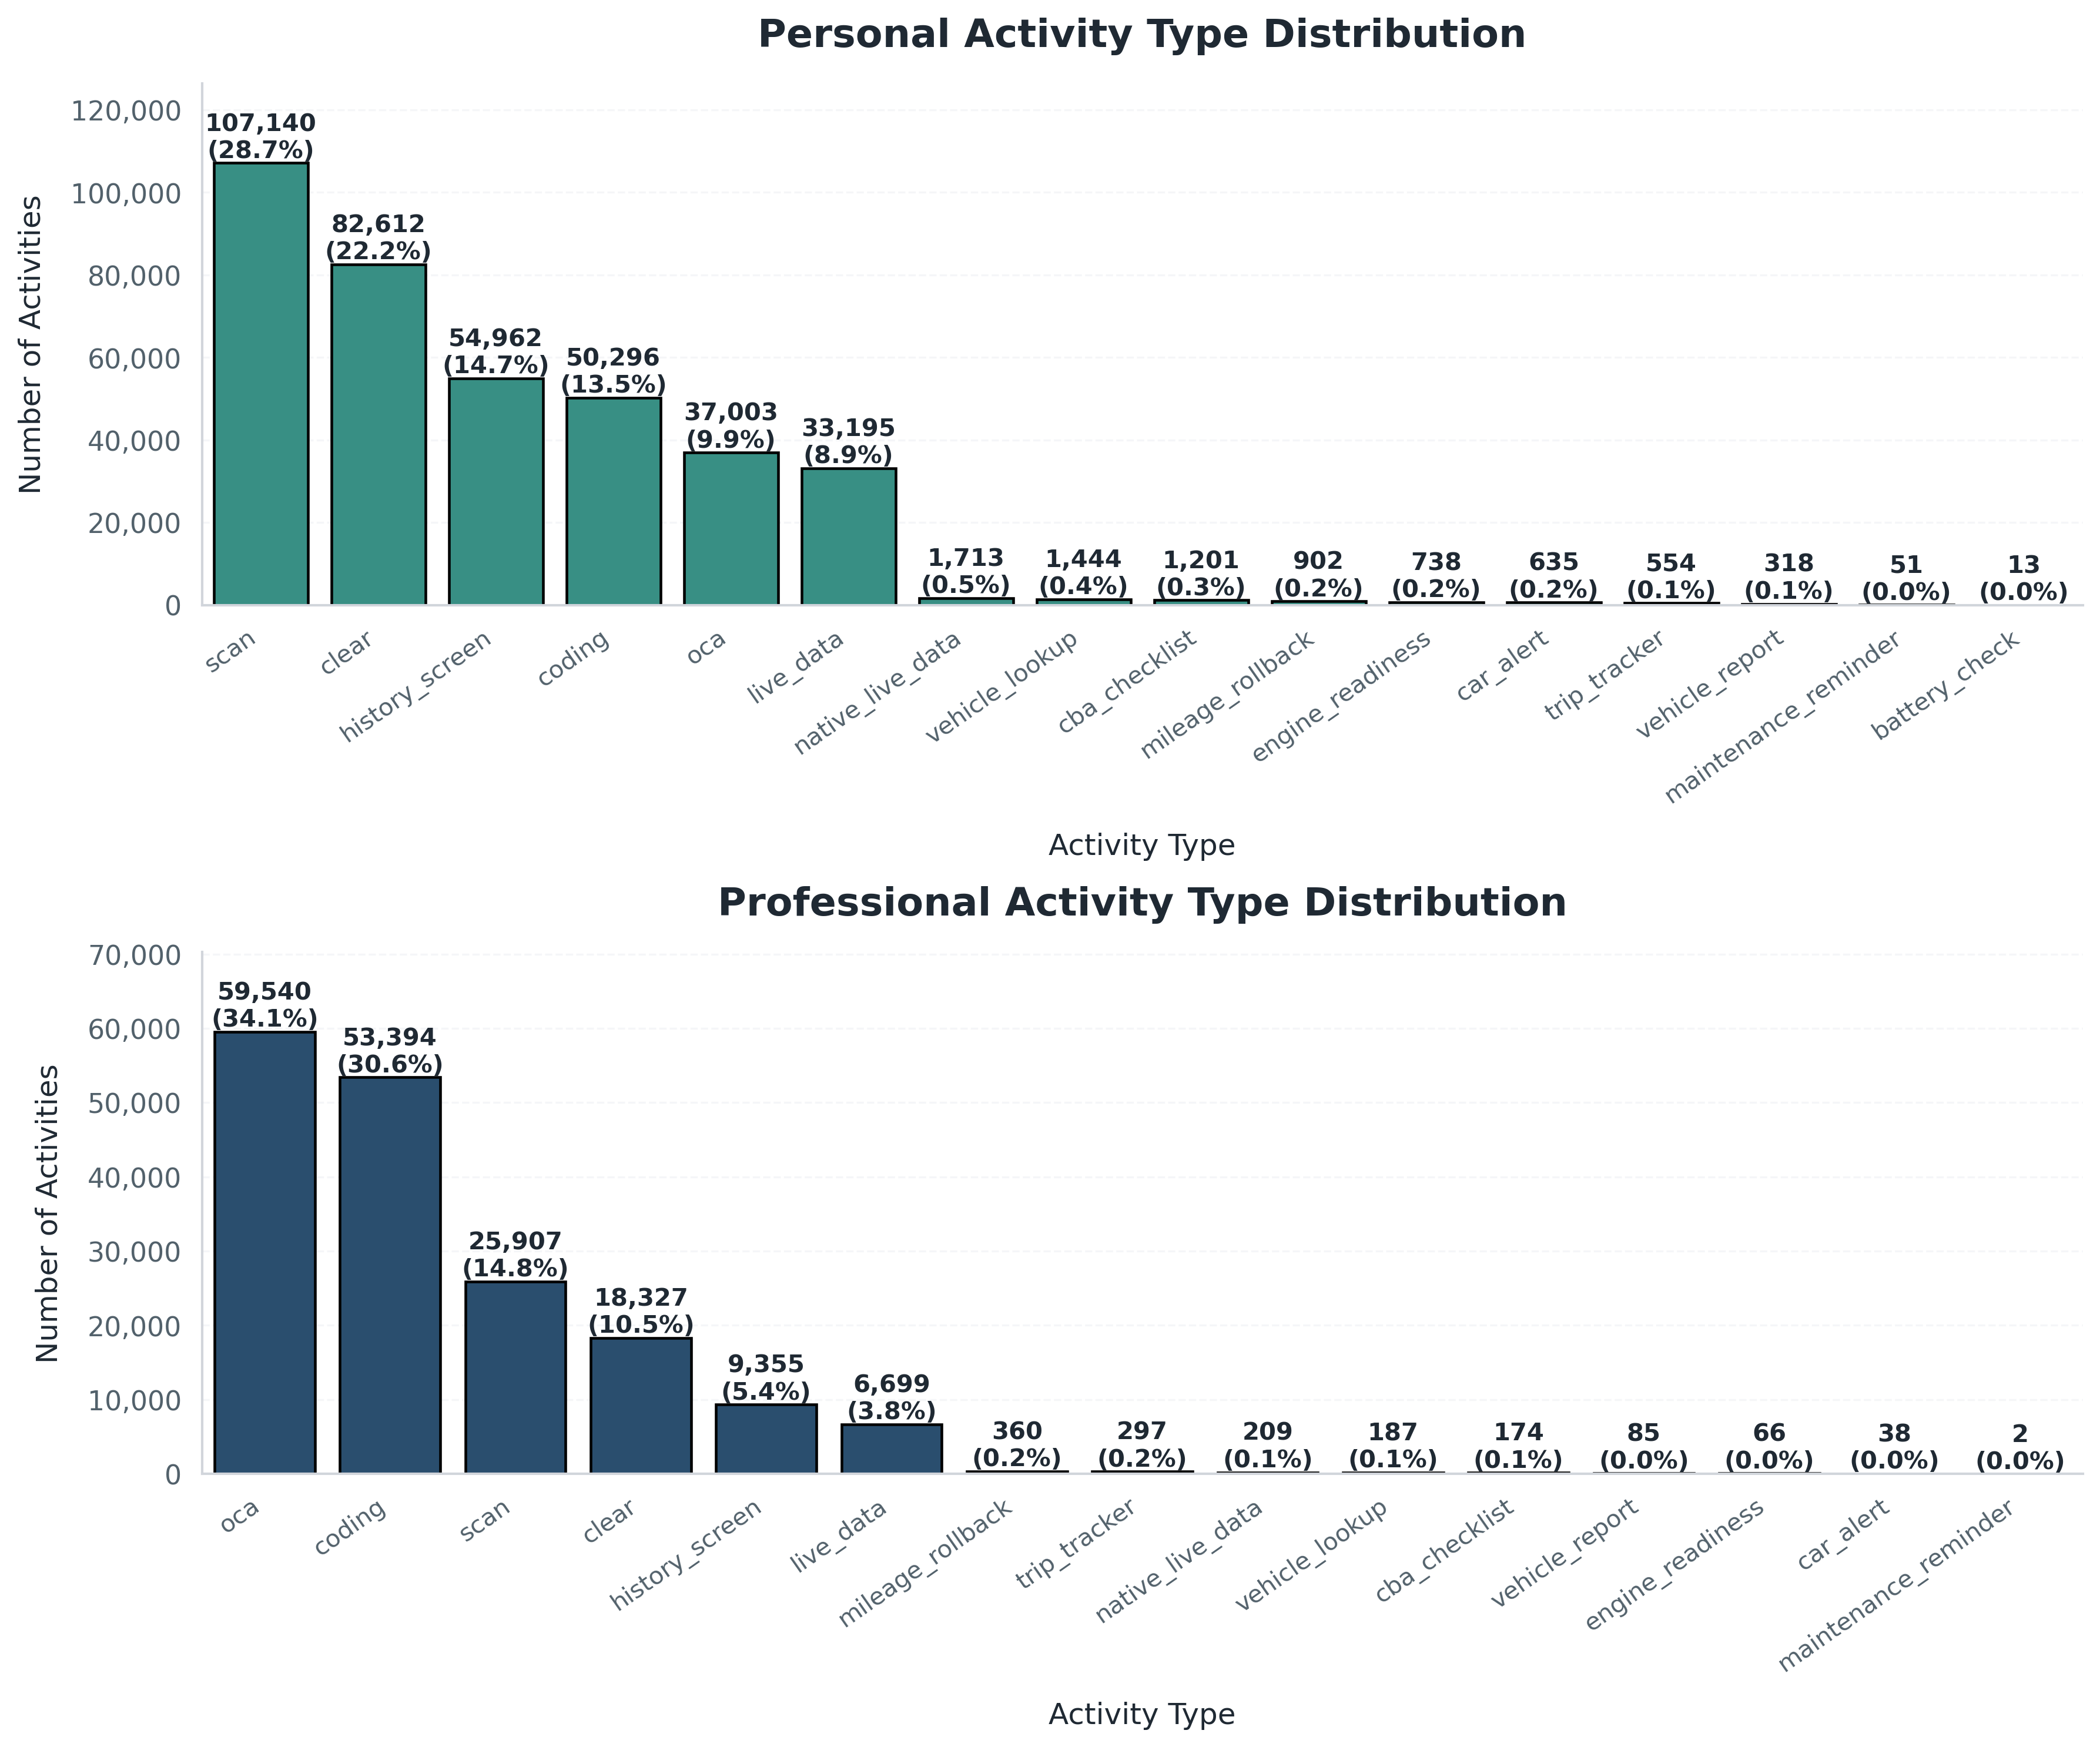

In [10]:
import seaborn as sns
import matplotlib.pyplot as plot
from matplotlib.ticker import StrMethodFormatter



def plot_activity_distribution(ax, df, title, color):
    activity_counts = (
        df["activity_type"]
        .value_counts()
        .sort_values(ascending=False)
    )

    total_activities = activity_counts.sum()
    sns.set_theme(**style.SEABORN_THEME)
    sns.barplot(
        x=activity_counts.index,
        y=activity_counts.values,
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=1.1
    )

    labels = [
        f"{count:,}\n({count / total_activities * 100:.1f}%)"
        for count in activity_counts.values
    ]

    for bar, label in zip(ax.patches, labels):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax.set_title(title, fontsize=16, fontweight="bold", pad=15)
    ax.set_xlabel("Activity Type", fontsize=12, labelpad=10)
    ax.set_ylabel("Number of Activities", fontsize=12, labelpad=10)

    ax.tick_params(axis="x", rotation=35, labelsize=10)
    ax.tick_params(axis="y", labelsize=11)

    for label in ax.get_xticklabels():
        label.set_ha("right")

    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(0, activity_counts.max() * 1.18)


fig, axes = plot.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 10),
    sharey=False
)

plot_activity_distribution(
    ax=axes[0],
    df=df_1000_personal,
    title="Personal Activity Type Distribution",
    color=style.PALETTE["Personal"]
)

plot_activity_distribution(
    ax=axes[1],
    df=df_1000_professional,
    title="Professional Activity Type Distribution",
    color=style.PALETTE["Professional"]
)

plot.tight_layout()
plot.show()

In [11]:


percentage_car_share_general = (
    merged_raw_1000
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_general = percentage_car_share_general.pow(2).groupby(level=0).sum()
n_general = percentage_car_share_general.groupby(level=0).size()
effective_hhi_general = 1 / hhi_general

effective_hhi_general.describe(percentiles=[0.25,0.50,0.75,0.8,0.90,0.95,0.99])

count    2755.000000
mean        3.891147
std        19.240130
min         1.000000
25%         1.067799
50%         1.784960
75%         2.910633
80%         3.396779
90%         5.696331
95%         9.428111
99%        32.517741
max       842.074508
Name: proportion, dtype: float64

In [12]:
personal_user_count = df_1000_personal["user_id"].nunique()
professional_user_count = df_1000_professional["user_id"].nunique()

print(
    f"Personal users: {personal_user_count}",
    f"Professional users: {professional_user_count}",sep="\n"
)


Personal users: 2381
Professional users: 260


2381 260


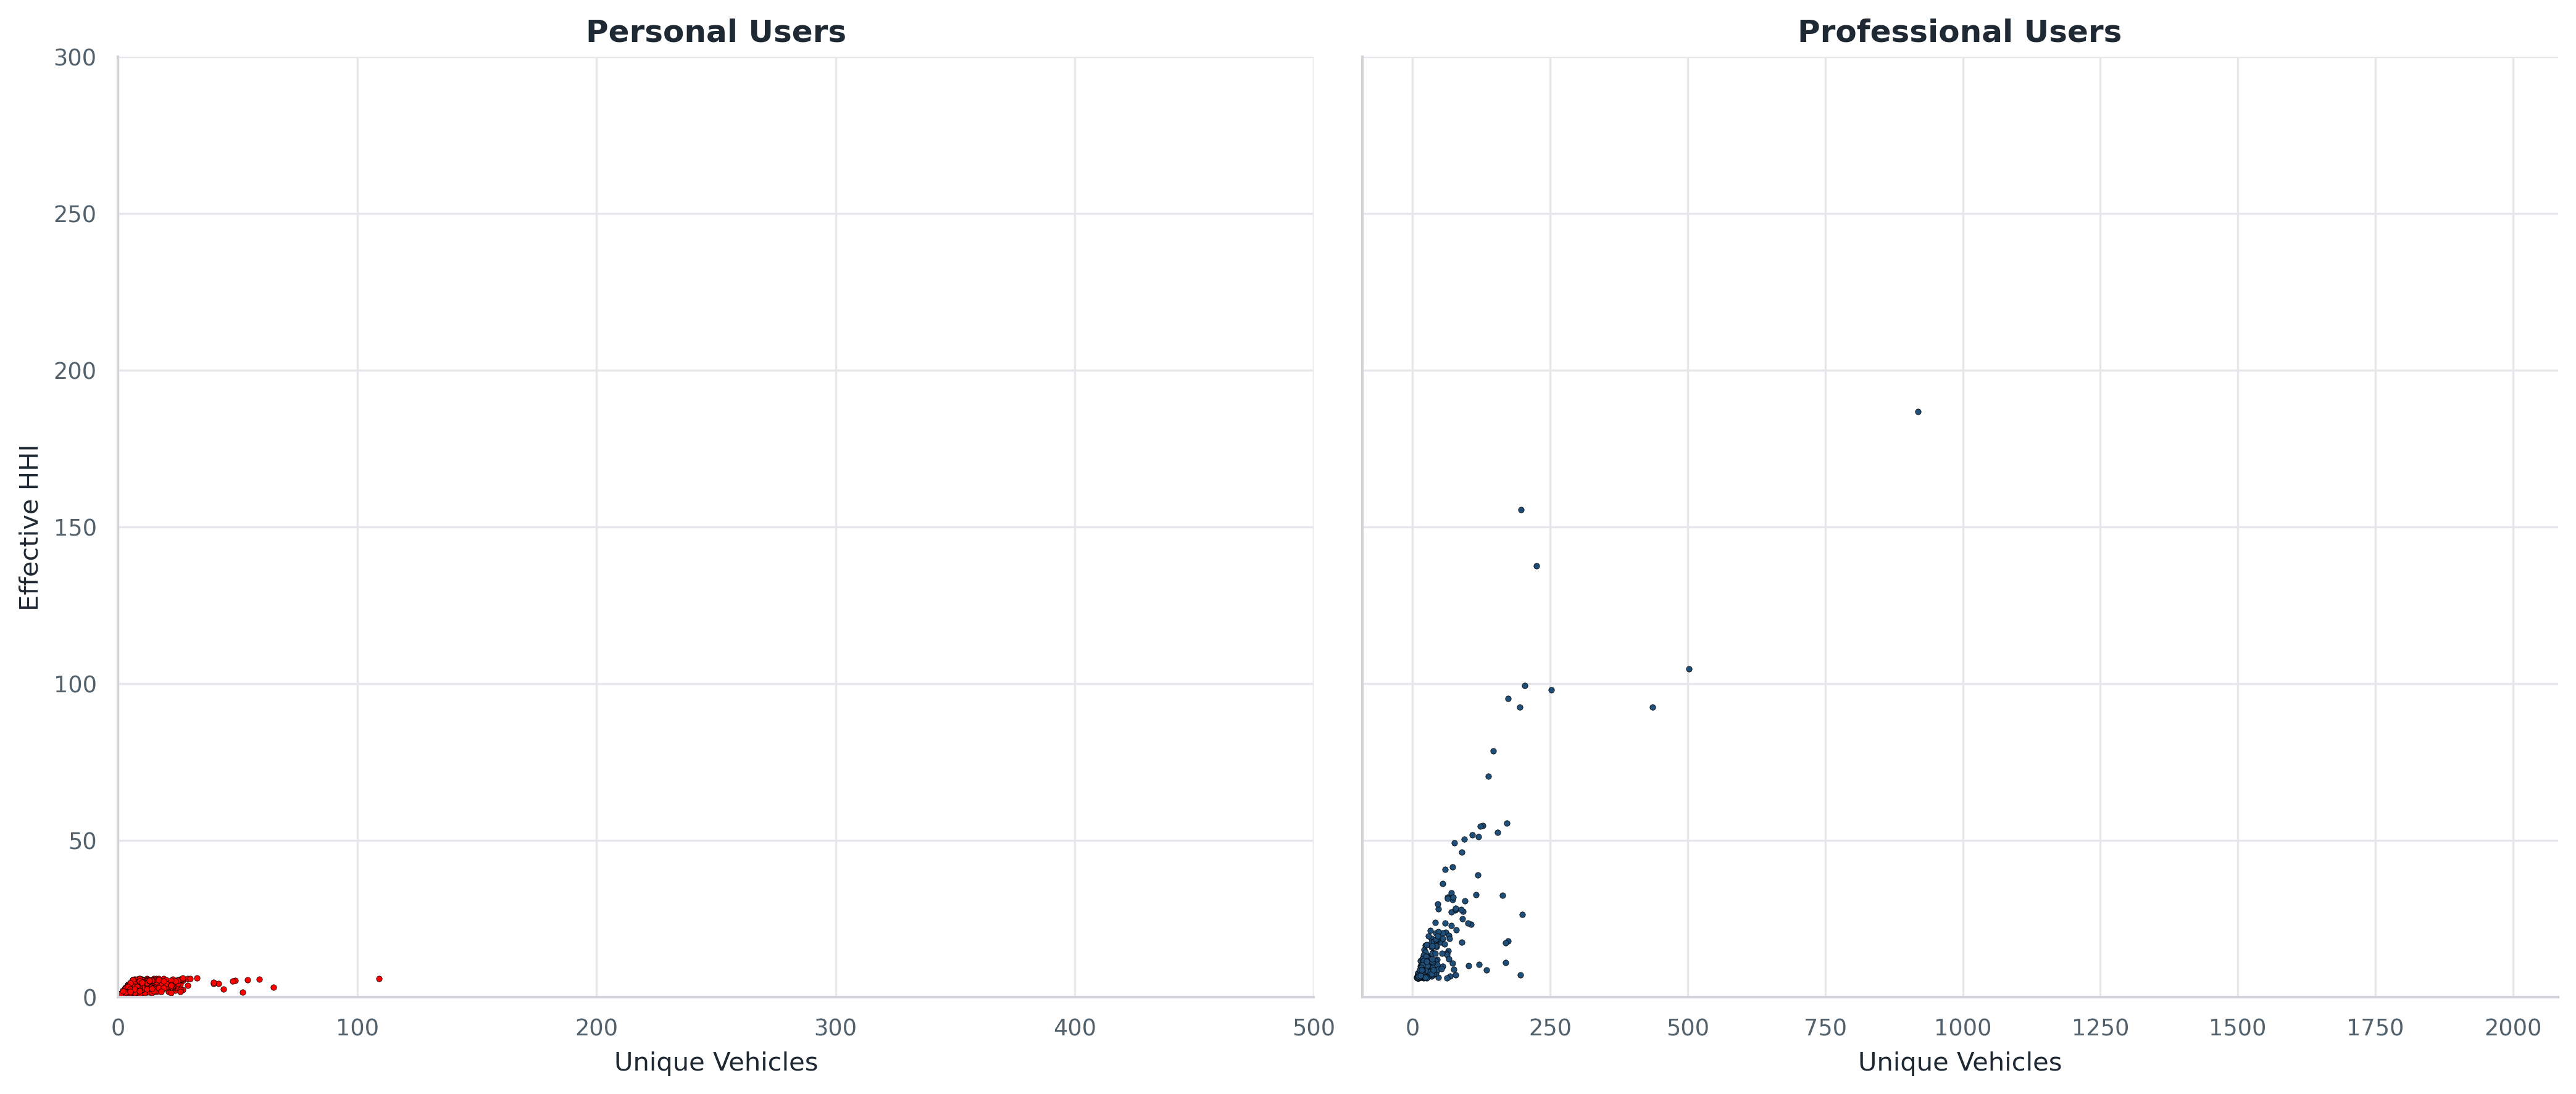

In [13]:
fig1, ax1 = plot.subplots(nrows=1, ncols=2, sharey=True)

# Personal
percentage_car_share_personal = (
    df_1000_personal
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_personal = percentage_car_share_personal.pow(2).groupby(level=0).sum()
n_personal = percentage_car_share_personal.groupby(level=0).size()
effective_hhi_personal = 1 / hhi_personal

sns.scatterplot(x=n_personal, y=effective_hhi_personal,
                ax=ax1[0], s=5, color="red", edgecolor="black")
ax1[0].set_ylabel("Effective HHI")
ax1[0].set_xlabel("Unique Vehicles")
ax1[0].set_title("Personal Users")
ax1[0].set_xlim(0, 500)
ax1[0].set_ylim(0,300)
# Professional
percentage_car_share_professional = (
    df_1000_professional
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_professional = percentage_car_share_professional.pow(2).groupby(level=0).sum()
n_professional = percentage_car_share_professional.groupby(level=0).size()
effective_hhi_professional = 1 / hhi_professional

sns.set_theme(**style.SEABORN_THEME)
sns.scatterplot(x=n_professional, y=effective_hhi_professional,
                ax=ax1[1], s=5, color=style.PALETTE["Professional"], edgecolor="black",
                )
ax1[1].set_ylabel("Effective HHI")
ax1[1].set_xlabel("Unique Vehicles")
ax1[1].set_title("Professional Users")


fig1.set_tight_layout(tight=True)
fig1.set_size_inches((14, 6))



print(len(hhi_personal),len(hhi_professional))



2381 260


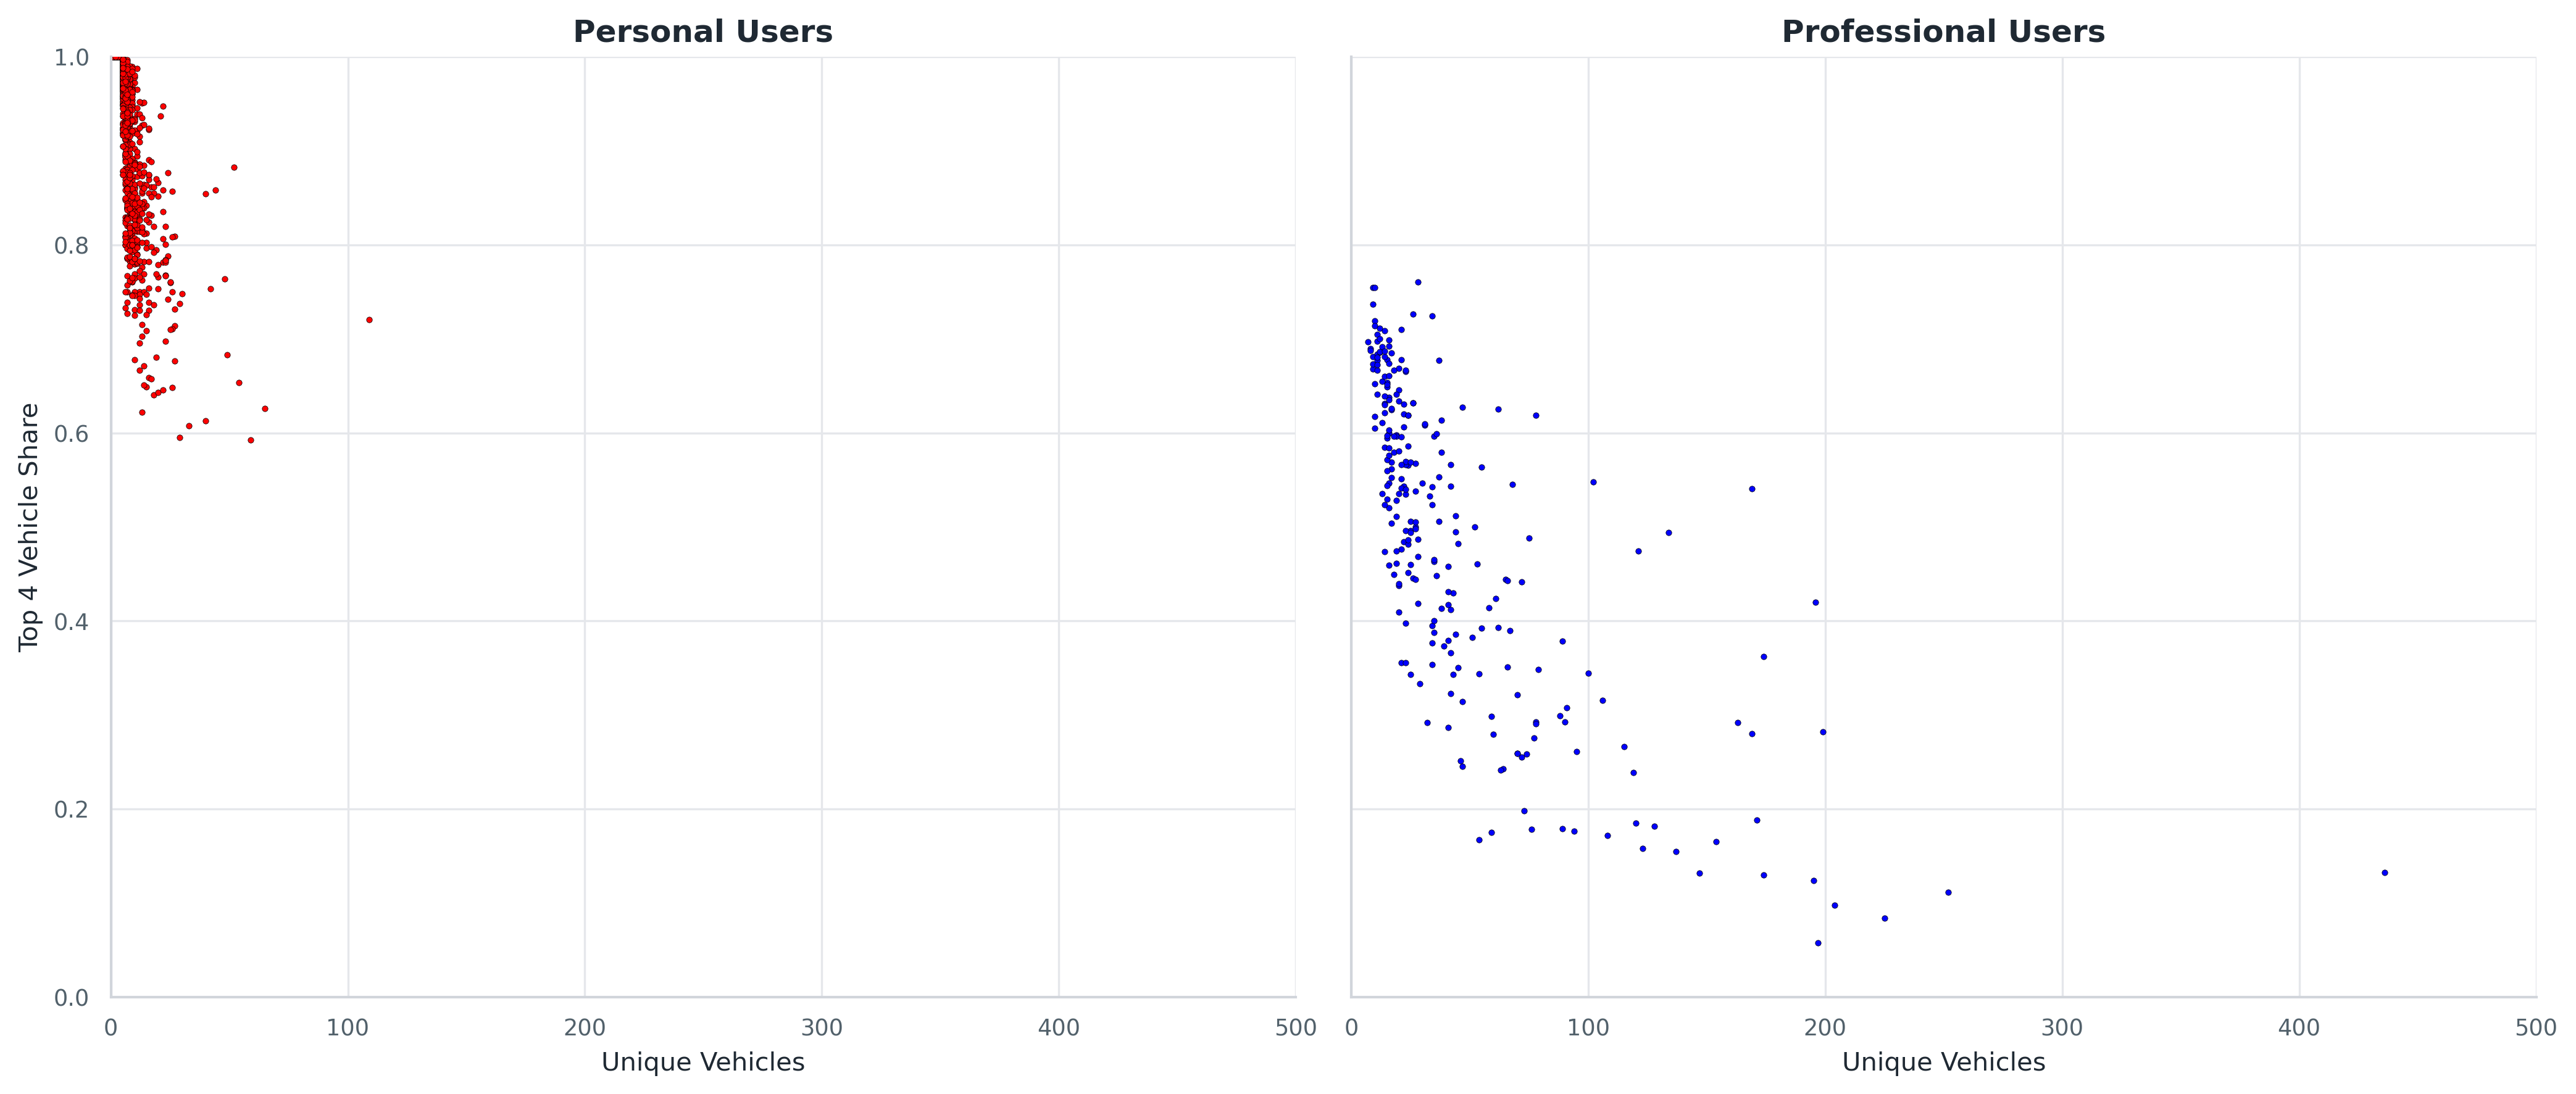

In [14]:
fig1, ax1 = plot.subplots(nrows=1, ncols=2, sharey=True)

# Personal
percentage_car_share_personal = (
    df_1000_personal
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

top4_share_personal = (
    percentage_car_share_personal
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

n_personal = percentage_car_share_personal.groupby(level=0).size()

sns.scatterplot(x=n_personal, y=top4_share_personal,
                ax=ax1[0], s=5, color="red", edgecolor="black")


ax1[0].set_ylabel("Top 4 Vehicle Share")
ax1[0].set_xlabel("Unique Vehicles")
ax1[0].set_title("Personal Users")
ax1[0].set_xlim(0, 500)
ax1[0].set_ylim(0, 1)

# Professional
percentage_car_share_professional = (
    df_1000_professional
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

top4_share_professional = (
    percentage_car_share_professional
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

n_professional = percentage_car_share_professional.groupby(level=0).size()

sns.scatterplot(x=n_professional, y=top4_share_professional,
                ax=ax1[1], s=5, color="blue", edgecolor="black")
ax1[1].set_ylabel("Top 4 Vehicle Share")
ax1[1].set_xlabel("Unique Vehicles")
ax1[1].set_title("Professional Users")
ax1[1].set_xlim(0, 500)

fig1.set_tight_layout(tight=True)
fig1.set_size_inches((14, 6))

print(len(top4_share_personal), len(top4_share_professional))

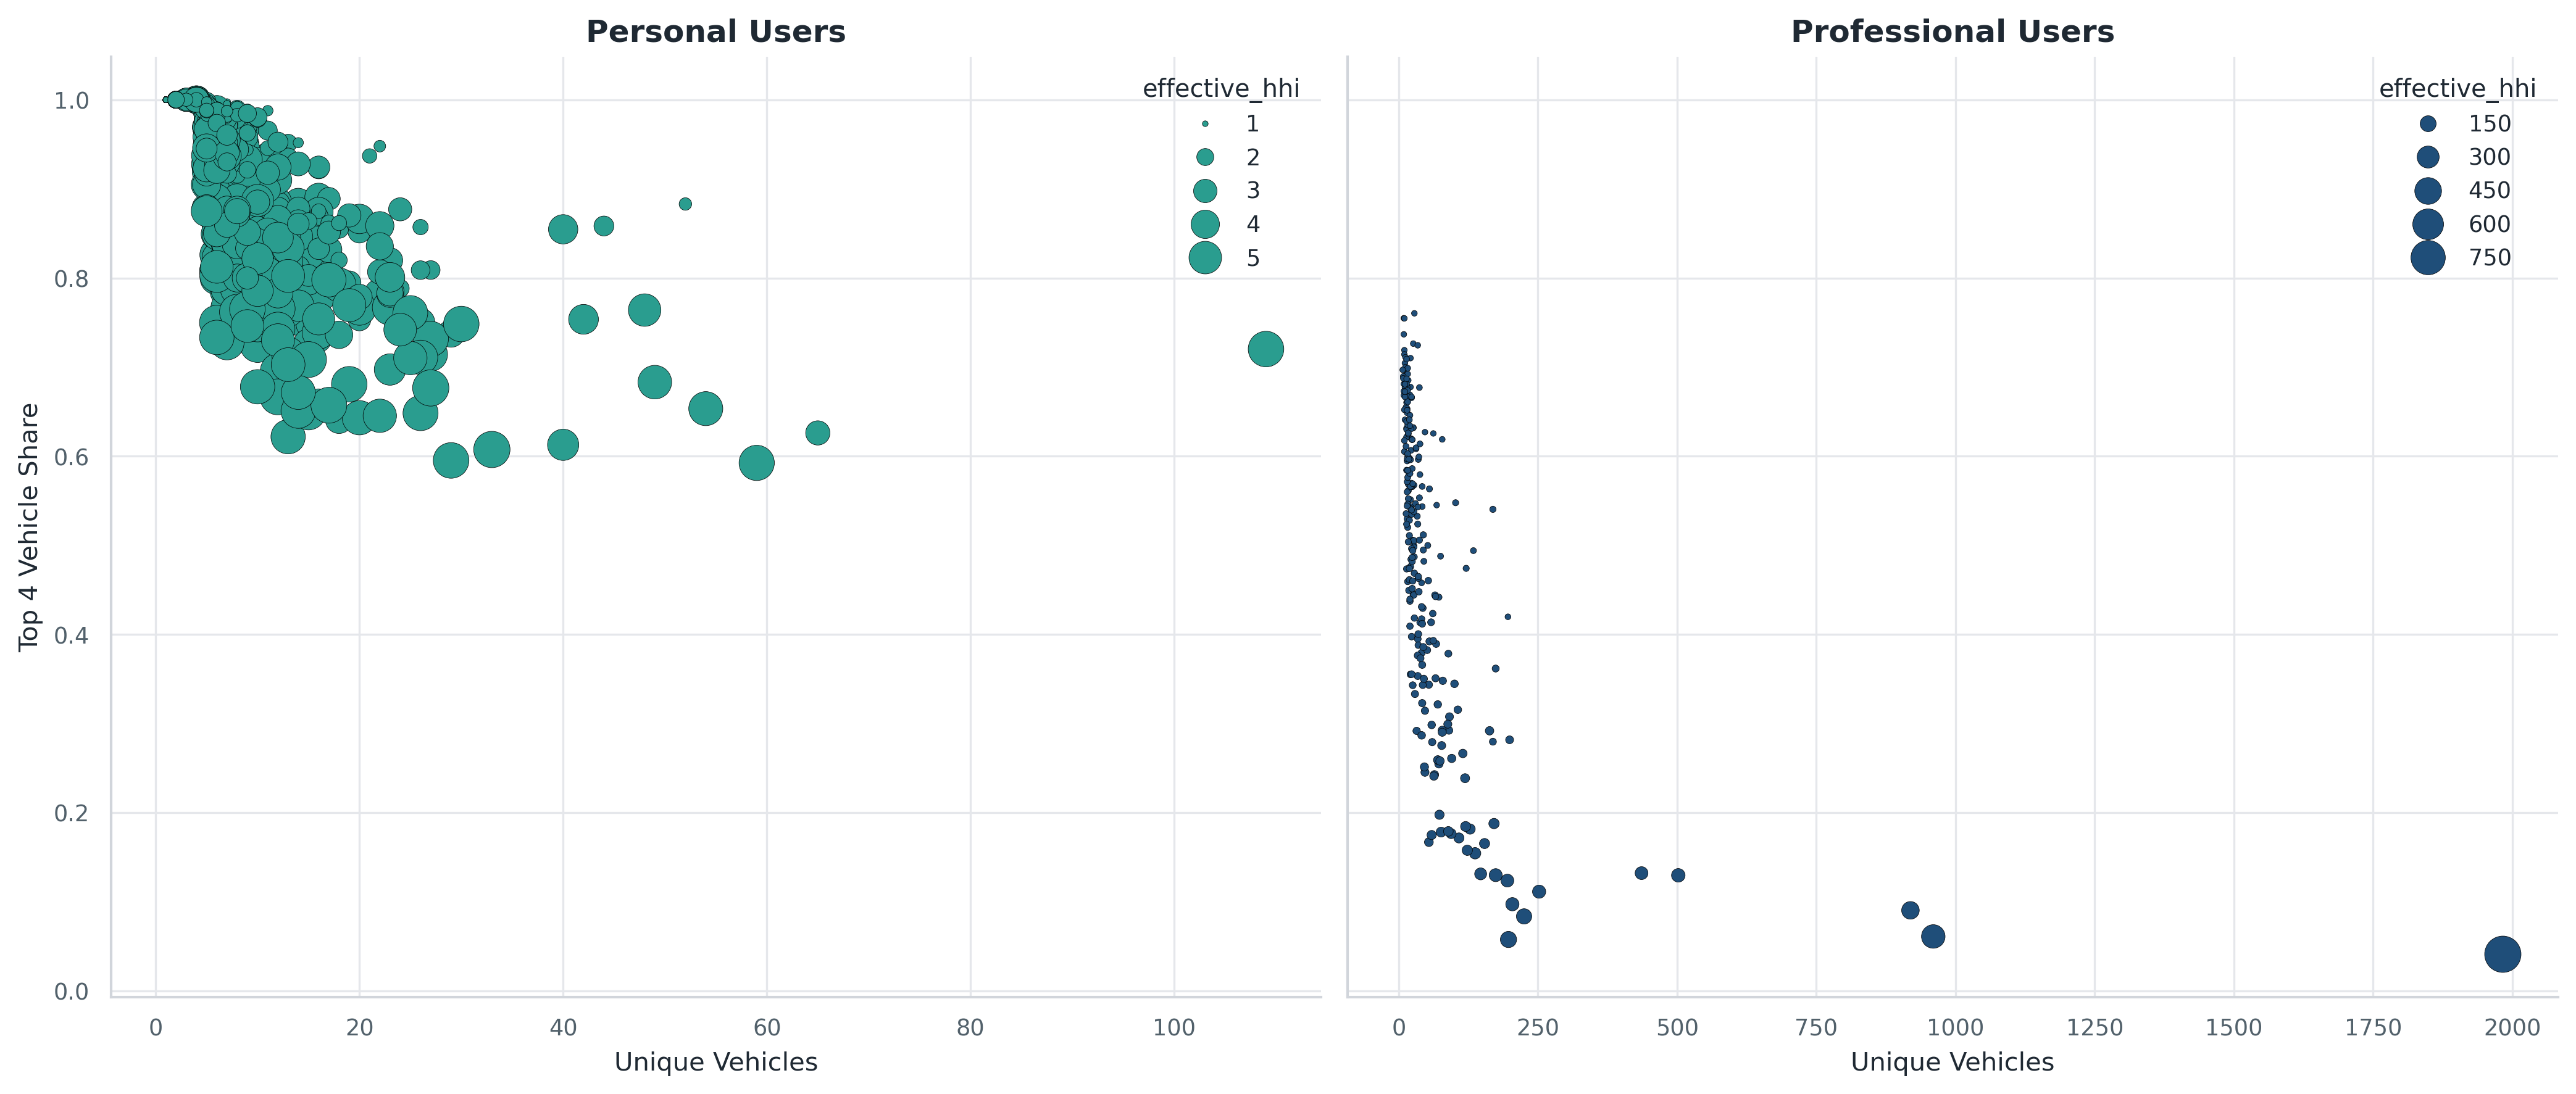

In [15]:
fig1, ax1 = plot.subplots(nrows=1, ncols=2, sharey=True)

# Personal
percentage_car_share_personal = (
    df_1000_personal
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

sns.set_theme(**style.SEABORN_THEME)

hhi_personal = percentage_car_share_personal.pow(2).groupby(level=0).sum()
effective_hhi_personal = 1 / hhi_personal
n_personal = percentage_car_share_personal.groupby(level=0).size()
top4_share_personal = (
    percentage_car_share_personal
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

combined_personal = pd.DataFrame({
    "n": n_personal,
    "top4_share": top4_share_personal,
    "effective_hhi": effective_hhi_personal
}).dropna()

sns.scatterplot(
    x=combined_personal["n"],
    y=combined_personal["top4_share"],
    size=combined_personal["effective_hhi"],
    ax=ax1[0], color=style.PALETTE["Personal"], edgecolor="black",
    sizes=(5, 200), legend=True
)
ax1[0].set_ylabel("Top 4 Vehicle Share")
ax1[0].set_xlabel("Unique Vehicles")
ax1[0].set_title("Personal Users")

# ax1[0].set_ylim(0, 1)

# Professional
percentage_car_share_professional = (
    df_1000_professional
    .groupby("user_id")["vehicle_id"]
    .value_counts(normalize=True)
)

hhi_professional = percentage_car_share_professional.pow(2).groupby(level=0).sum()
effective_hhi_professional = 1 / hhi_professional
n_professional = percentage_car_share_professional.groupby(level=0).size()
top4_share_professional = (
    percentage_car_share_professional
    .groupby("user_id")
    .apply(lambda x: x.iloc[:4].sum() if len(x) >= 4 else x.sum())
)

combined_professional = pd.DataFrame({
    "n": n_professional,
    "top4_share": top4_share_professional,
    "effective_hhi": effective_hhi_professional
}).dropna()

sns.scatterplot(
    x=combined_professional["n"],
    y=combined_professional["top4_share"],
    size=combined_professional["effective_hhi"],
    ax=ax1[1], color=style.PALETTE["Professional"], edgecolor="black",
    sizes=(5, 200), legend=True
)
ax1[1].set_ylabel("Top 4 Vehicle Share")
ax1[1].set_xlabel("Unique Vehicles")
ax1[1].set_title("Professional Users")


fig1.set_tight_layout(tight=True)
fig1.set_size_inches((14, 6))



# Analysing Usage Patterns (frequency of usage + inactivity distribution)

In [16]:
activity_df_1000.isnull().sum()

user_id              0
vehicle_id       13117
activity_date        0
app                  0
activity_type        0
dtype: int64

Personal Users:
 count    80426.000000
mean        17.951569
std         49.478523
min          0.083333
25%          0.833333
50%          3.125000
75%         13.656250
90%         44.083333
95%         83.197917
99%        228.833333
max       2142.875000
Name: activity_date, dtype: float64

Professional Users:
 count    25884.000000
mean         7.814266
std         24.607236
min          0.083333
25%          0.750000
50%          1.958333
75%          6.125000
90%         16.958333
95%         31.041667
99%         94.632917
max       1012.250000
Name: activity_date, dtype: float64


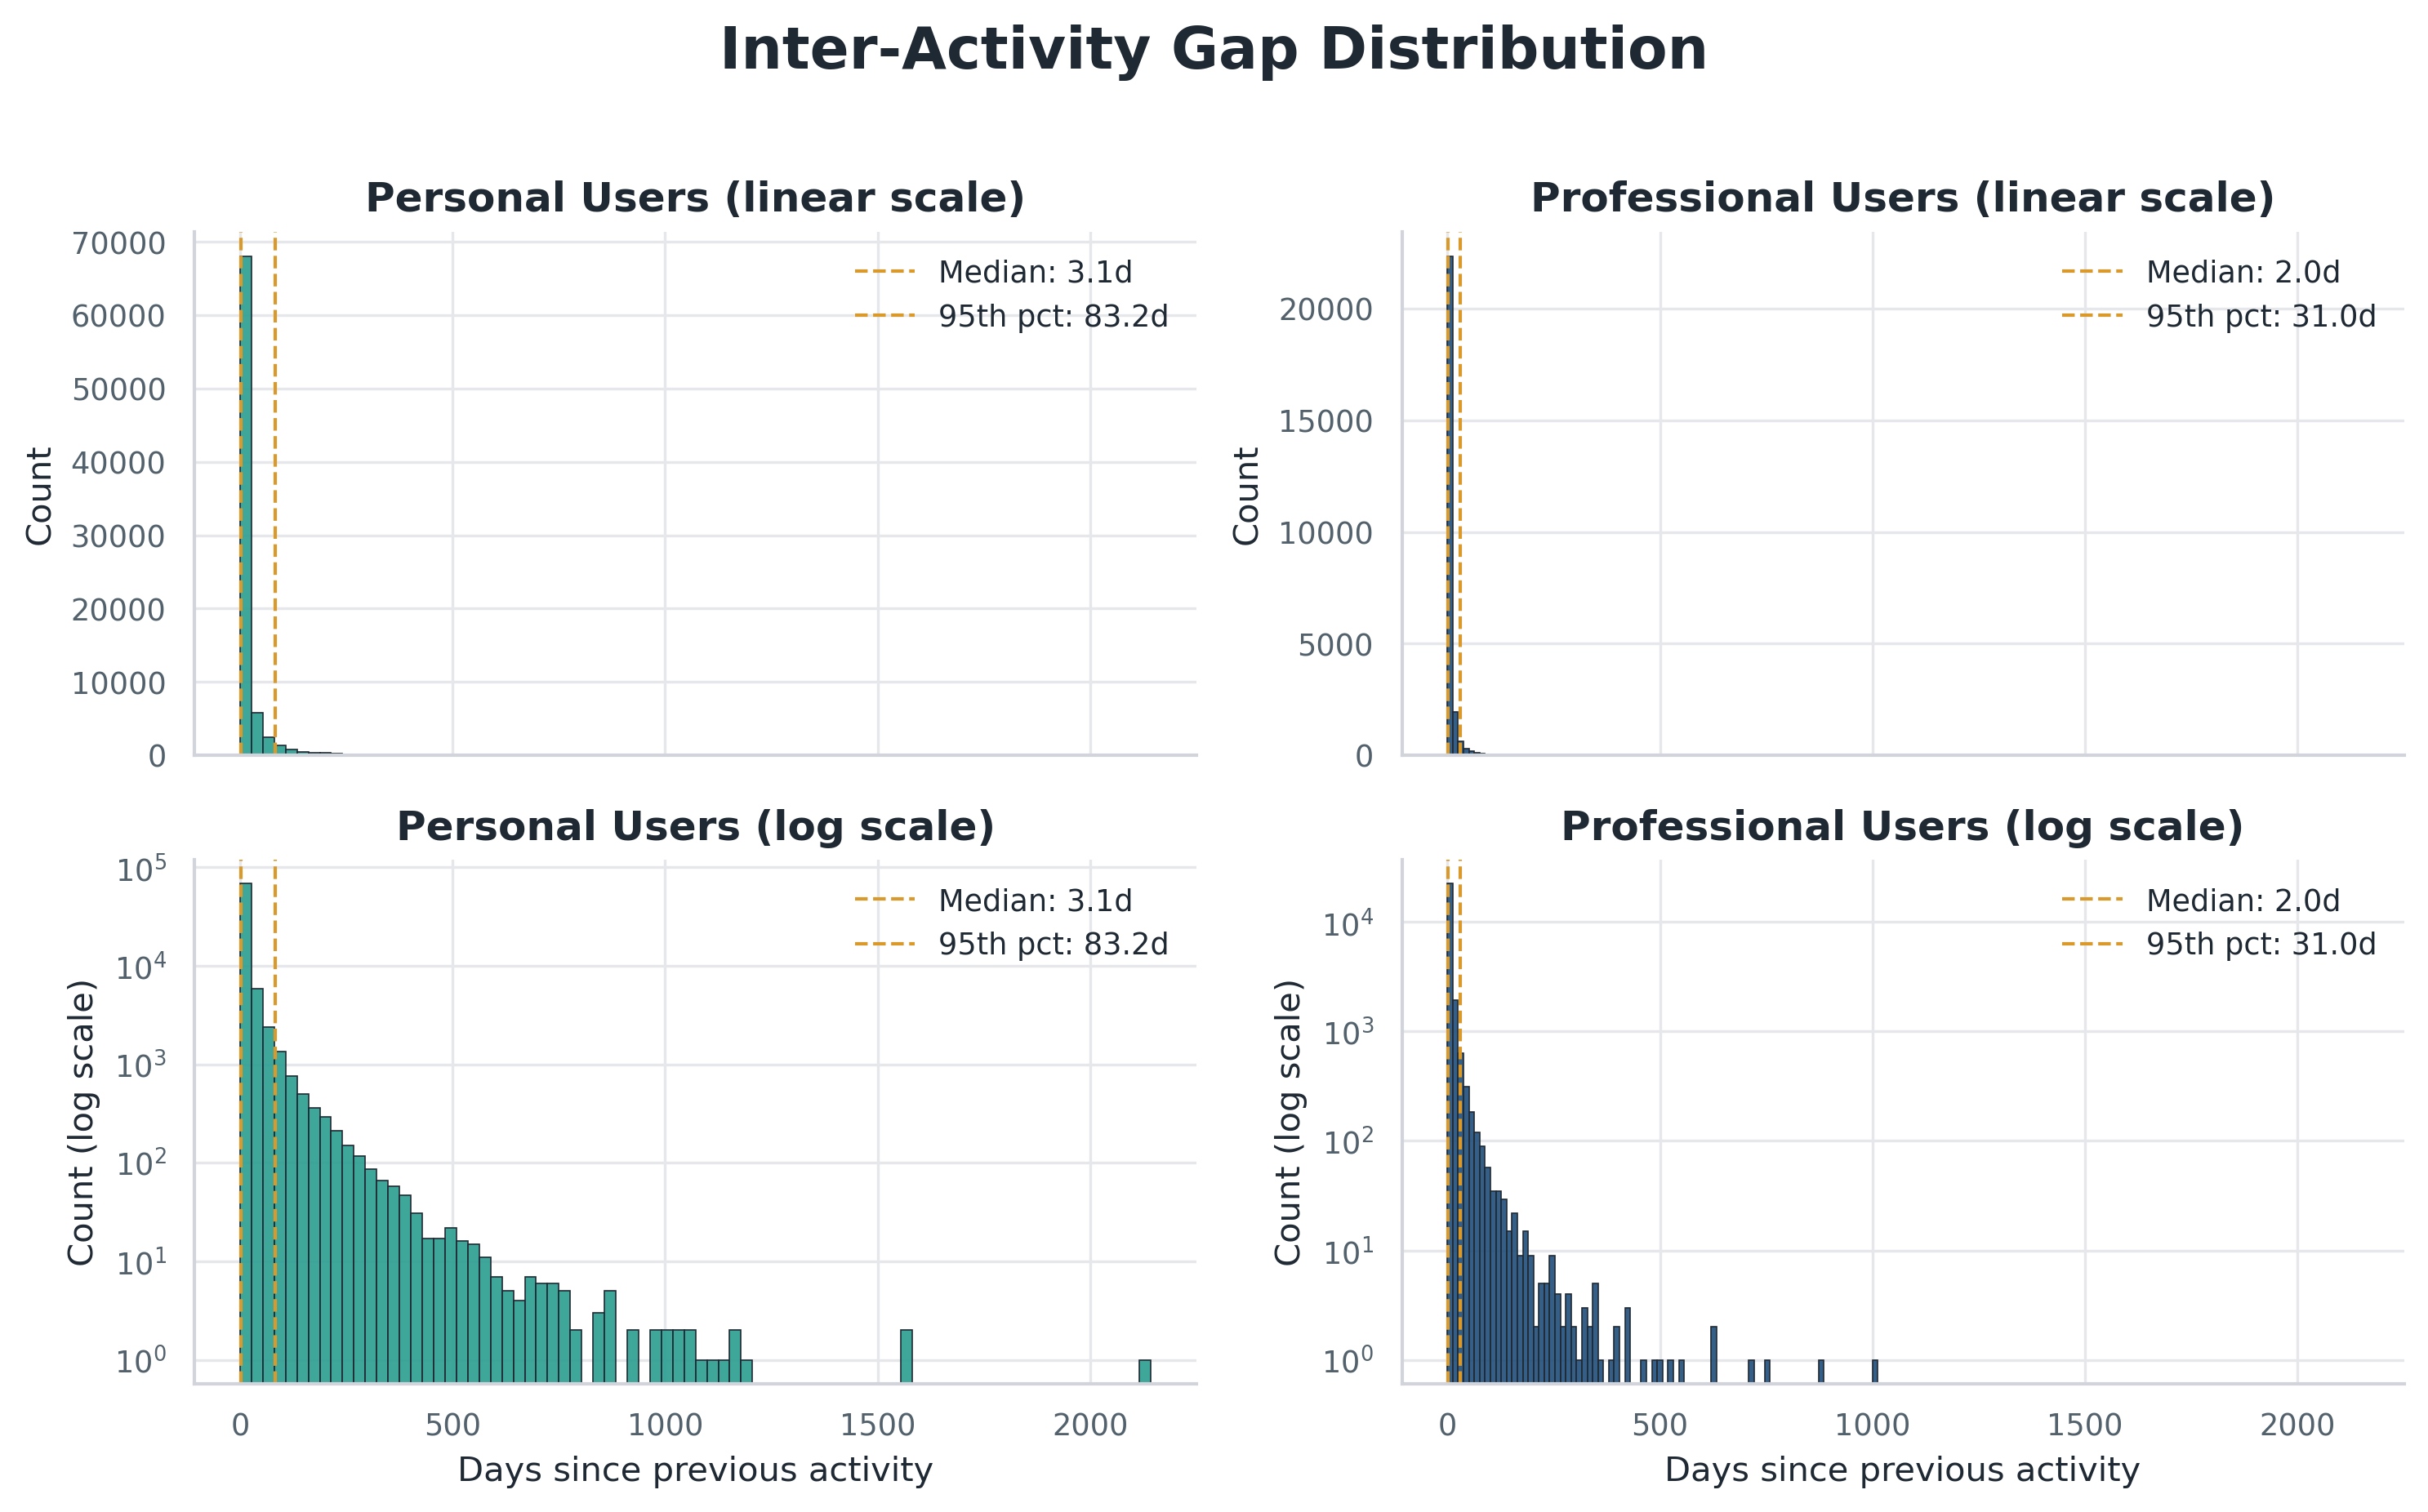

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Apply thesis style
sns.set_theme(**style.SEABORN_THEME)

PERSONAL_COLOR = style.PALETTE["Personal"]
PROFESSIONAL_COLOR = style.PALETTE["Professional"]
ACCENT_COLOR = style.COLORS["accent"]
EDGE_COLOR = style.COLORS["text"]
BACKGROUND = style.COLORS["background"]


def calculate_inter_activity_gap_days(df):
    """
    Calculate days since previous activity per user.
    Removes gaps <= 1 hour and trims values above the 99th percentile.
    """
    df = df.copy()

    df["activity_date"] = pd.to_datetime(df["activity_date"])
    df = df.sort_values(by=["user_id", "activity_date"])

    time_diff = (
        df["activity_date"]
        - df.groupby("user_id")["activity_date"].shift(1)
    )

    time_diff_hours = time_diff.dt.total_seconds().div(3600).round()
    time_diff_hours = time_diff_hours[time_diff_hours > 1]


    return time_diff_hours / 24


# Calculate inter-activity gaps
time_diff_personal = calculate_inter_activity_gap_days(df_1000_personal)
time_diff_professional = calculate_inter_activity_gap_days(df_1000_professional)


# Plot setup
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    sharex=True,
    figsize=(10, 6)
)

fig.patch.set_facecolor(BACKGROUND)

plot_data = [
    {
        "data": time_diff_personal,
        "color": PERSONAL_COLOR,
        "title": "Personal Users"
    },
    {
        "data": time_diff_professional,
        "color": PROFESSIONAL_COLOR,
        "title": "Professional Users"
    }
]


for col, group in enumerate(plot_data):
    data = group["data"]
    color = group["color"]
    title = group["title"]

    for row, use_log_scale in enumerate([False, True]):
        ax = axes[row, col]
        ax.set_facecolor(BACKGROUND)

        sns.histplot(
            data=data,
            bins=80,
            color=color,
            edgecolor=EDGE_COLOR,
            linewidth=0.4,
            alpha=0.9,
            ax=ax
        )

        if use_log_scale:
            ax.set_yscale("log")
            ax.set_ylabel("Count (log scale)")
            scale_label = "log scale"
        else:
            ax.set_ylabel("Count")
            scale_label = "linear scale"

        ax.set_xlabel("Days since previous activity")
        ax.set_title(f"{title} ({scale_label})")

        # Median and 95th percentile reference lines
        for percentile, label in [(0.5, "Median"), (0.95, "95th pct")]:
            value = data.quantile(percentile)

            ax.axvline(
                value,
                color=ACCENT_COLOR,
                linestyle="--",
                linewidth=1,
                label=f"{label}: {value:.1f}d"
            )

        ax.legend()
        sns.despine(ax=ax)


fig.suptitle(
    "Inter-Activity Gap Distribution",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

fig.tight_layout()


print(
    "Personal Users:\n",
    time_diff_personal.describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

print()

print(
    "Professional Users:\n",
    time_diff_professional.describe(
        percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

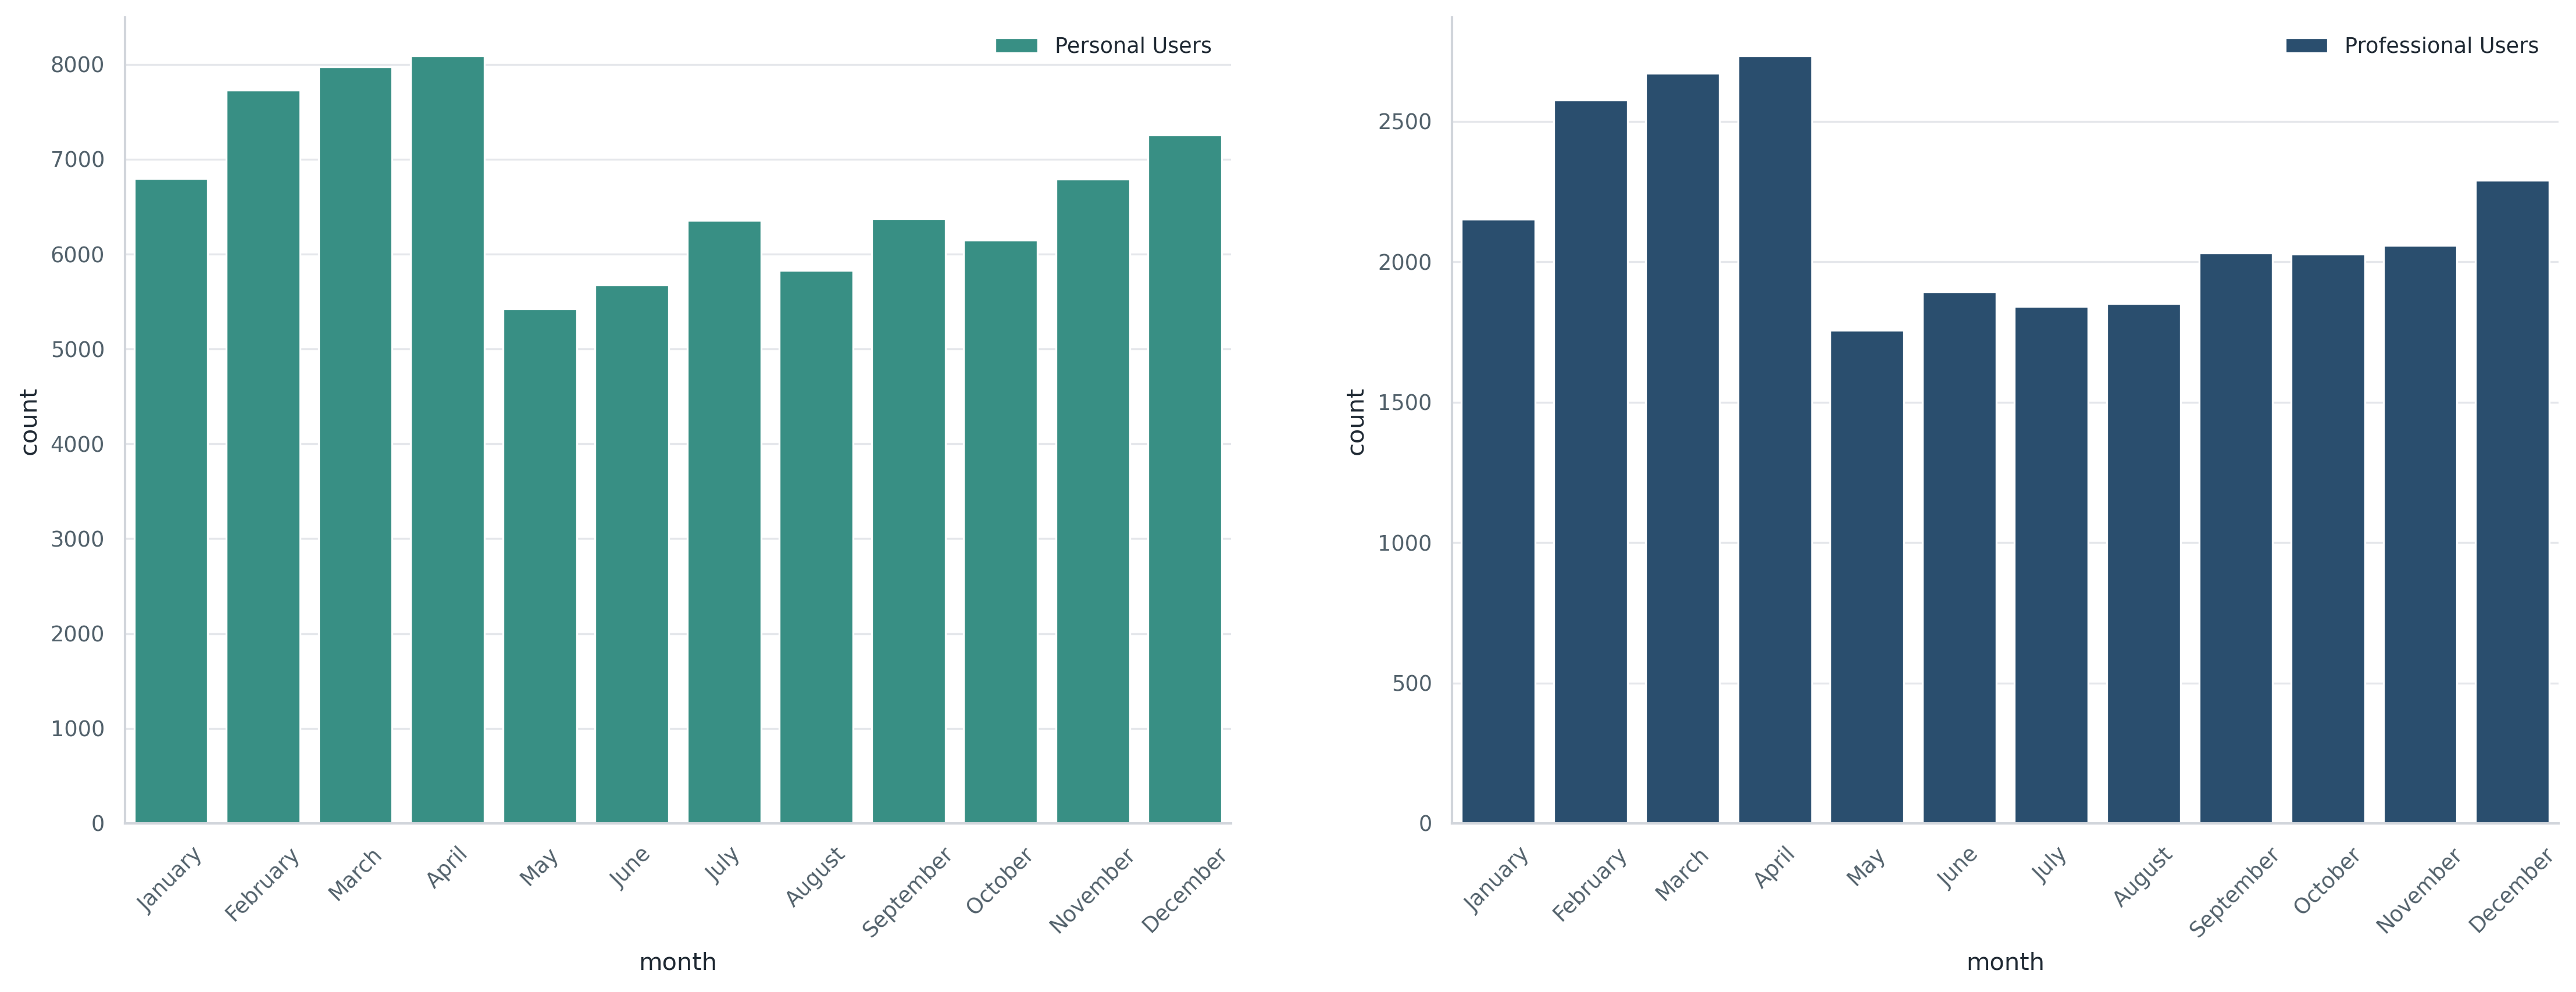

In [18]:
# df_1000_personal["activity_date"].dt.month_name()
fig_usage, ax_usage = plot.subplots(nrows=1, ncols=2)
df = df_1000_personal.copy()

df["activity_date"] = pd.to_datetime(df["activity_date"])
df = df.sort_values(by=["user_id", "activity_date"])

time_diff = (
      df["activity_date"]
      - df.groupby("user_id")["activity_date"].shift(1)
)

time_diff_hours = time_diff.dt.total_seconds().div(3600).round()
filtered_time  = time_diff_hours[time_diff_hours > 1]

df = df_1000_professional.copy()

df["activity_date"] = pd.to_datetime(df["activity_date"])
df = df.sort_values(by=["user_id", "activity_date"])

time_diff = (
      df["activity_date"]
      - df.groupby("user_id")["activity_date"].shift(1)
)

time_diff_hours = time_diff.dt.total_seconds().div(3600).round()
filtered_time_p = time_diff_hours[time_diff_hours > 1]




plot_df_usage   = df_1000_personal.loc[filtered_time.index, ["activity_date"]].copy()
plot_df_usage_p = df_1000_professional.loc[filtered_time_p.index, ["activity_date"]].copy()

plot_df_usage["activity_date"] = pd.to_datetime(plot_df_usage["activity_date"])
plot_df_usage_p["activity_date"] = pd.to_datetime(plot_df_usage_p["activity_date"])

plot_df_usage["month"]   = plot_df_usage["activity_date"].dt.month_name()
plot_df_usage_p["month"] = plot_df_usage_p["activity_date"].dt.month_name()


sns.set_theme(**style.SEABORN_THEME)
sns.countplot(data=plot_df_usage,
              x="month",
              ax=ax_usage[0],
              order=[
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"],
        color=style.PALETTE["Personal"],
        label="Personal Users")
sns.countplot(data=plot_df_usage_p,
              x="month",
              ax=ax_usage[1],
              order=[
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"],
        color=style.PALETTE["Professional"],
        label="Professional Users")

fig_usage.set_size_inches(w=18,h=6)
fig.tight_layout()


for _ax in ax_usage:
    _ax: Axes
    _ax.tick_params(axis='x',labelrotation=45)

In [19]:
df_1000_personal.sort_values(["user_id","activity_date"])

df_1000_personal["activity_date"].dt.isocalendar()

,year,week,day
0,2025,40,7
3,2026,11,2
4,2025,21,5
5,2025,40,6
6,2024,43,7
...,...,...,...
568299,2026,17,2
568300,2026,11,6
568301,2026,10,7
568303,2026,11,6


### NOTE:

The below code is not a full representation of what's going on (it's accurate enoguh though). The reasoning is that when applying data cleaner class get_cleaned_data() function it sets a cutoff date max.date - set_threshold. The cutoff filtering happened way before the code written below and therefore could include users that would not have yet had the time to experience hte event.

In [25]:


churn_threshold_personal = [70,160,180]

for threshold in churn_threshold_personal:

    n_churners = data_cleaner_1000.filter_after_inactivity(df_1000_personal,threshold_value=threshold)["churn_triggered"].sum()
    print(n_churners)



1776
980
850


<Axes: >

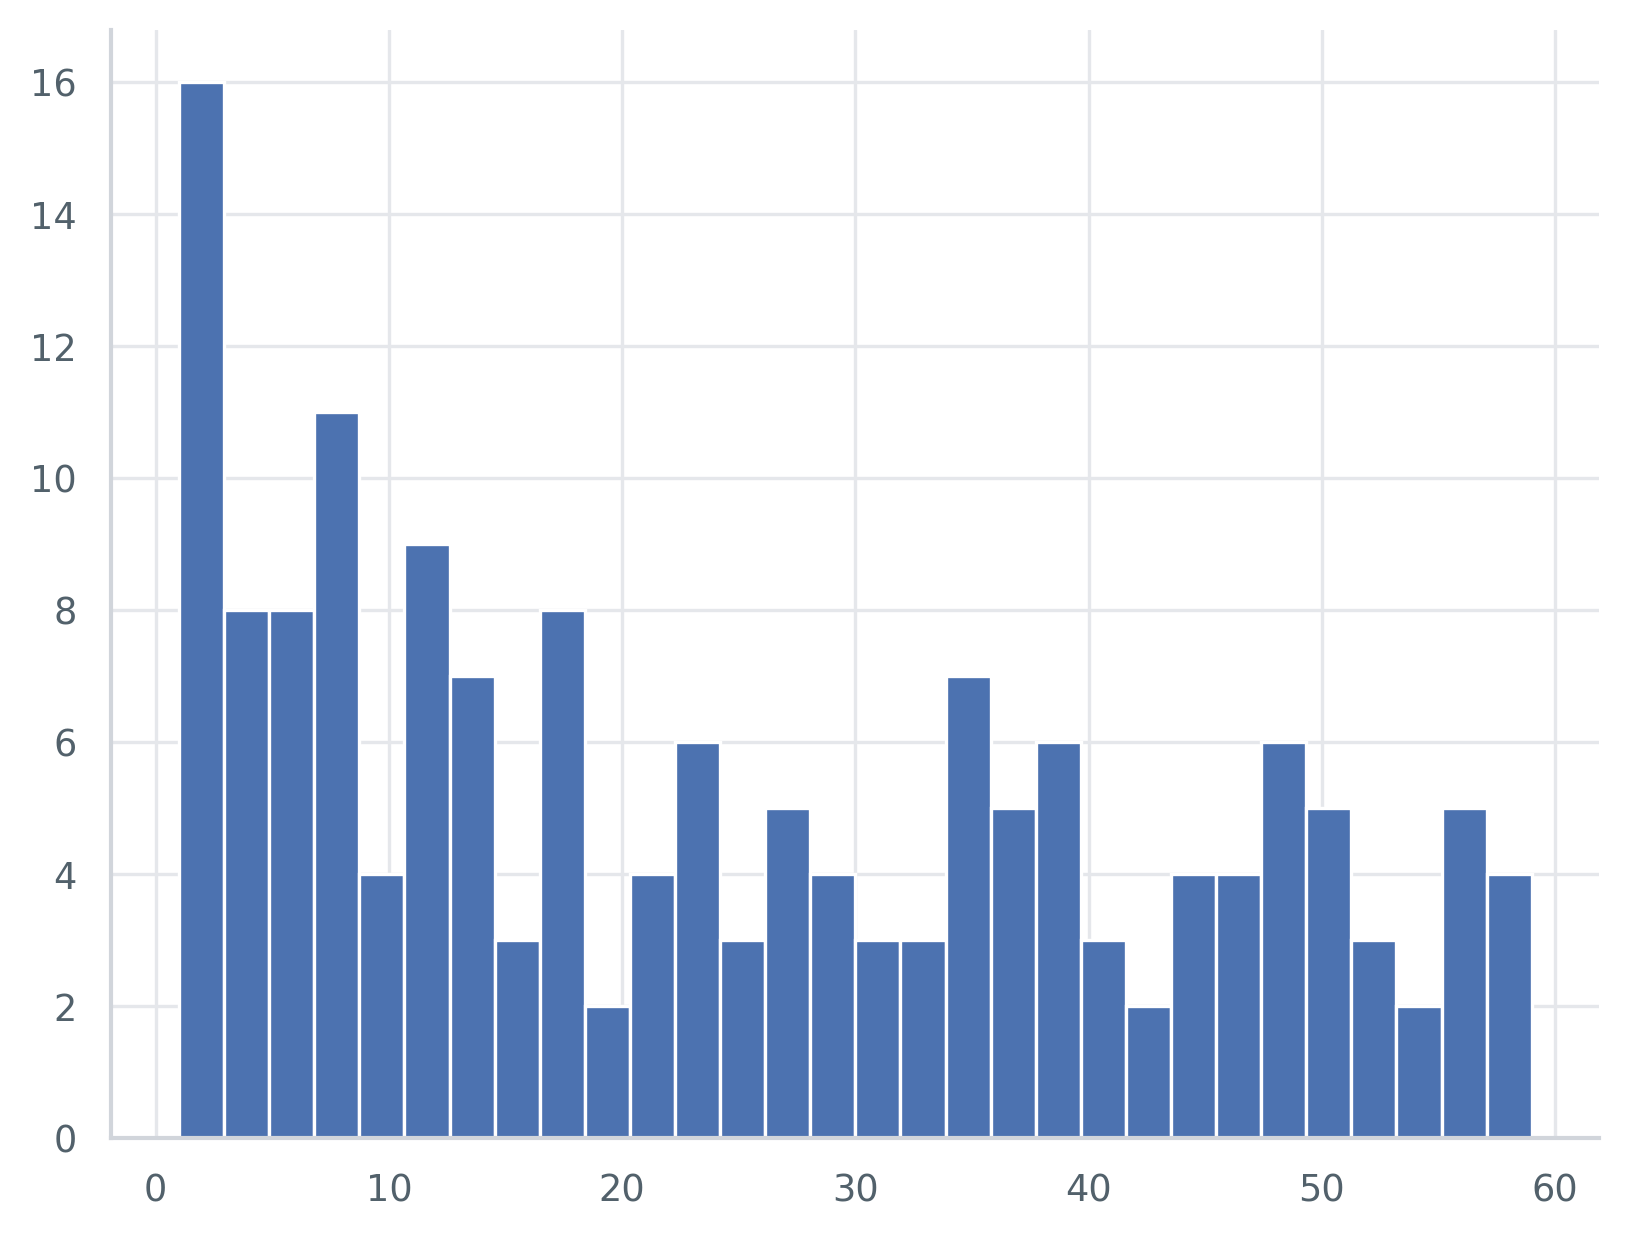

In [21]:
observation_windows = df_1000_personal.groupby("user_id")["activity_date"].max() - df_1000_personal.groupby("user_id")["activity_date"].min()

short = observation_windows.dt.days
short[short < 60].hist(bins=30)


In [22]:
churn_threshold_professional = [27,60, 90]

for threshold in churn_threshold_professional:

    n_churners = data_cleaner_1000.filter_after_inactivity(df_1000_professional,threshold_value=threshold)["churn_triggered"].sum()
    print(n_churners)



233
182
132


In [23]:

vehicle_ids_present = pd.Series(activity_df_1000["vehicle_id"].unique()).isin(vehicle_df_1000["vehicle_id"].unique()).sum()

percentage = (int(activity_df_1000["vehicle_id"].nunique()) - int(vehicle_ids_present)) / int(activity_df_1000["vehicle_id"].nunique()) 


print(f"Percentage of 'vehicle_id' metadata missing {percentage*100:.2f}%")




Percentage of 'vehicle_id' metadata missing 0.00%


In [24]:
vehicle_df_1000["vehicle_make"].unique()


vehicle_df_1000["vehicle_make"].value_counts()

vehicle_make
Volkswagen       13992
Audi              9442
Skoda             3467
Seat              2026
BMW               1003
Porsche            250
Mercedes-Benz      177
Ford               128
Toyota             113
MINI                56
MAN                 28
Lexus               23
Lamborghini         22
Bentley             17
BMW Moto            11
Toyota GR            2
Name: count, dtype: int64